<a href="https://colab.research.google.com/github/lakshlahoti15/MDS_LAB/blob/main/MDS_WEEK_6%2C7%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Using the 'Advertising Budget and Sales.csv' dataset
# Select 'TV Ad Budget ($)' as the independent variable (X)
# and 'Sales ($)' as the dependent variable (y)

X = advert_df['TV Ad Budget ($)']
y = advert_df['Sales ($)']

# Create a DataFrame for convenience, though not strictly necessary for statsmodels
df_advert = pd.DataFrame({'TV_Ad_Budget': X, 'Sales': y})

display(df_advert.head())

,TV_Ad_Budget,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


Now, let's fit a simple linear regression model using `statsmodels`.

In [11]:
# Add a constant to the independent variable for the intercept term
X_const = sm.add_constant(df_advert['TV_Ad_Budget'])

# Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(df_advert['Sales'], X_const)
results = model.fit()

# Display the model summary
print(results.summary())

# Get predicted values
df_advert['y_pred'] = results.predict(X_const)
# Get residuals
df_advert['residuals'] = results.resid

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.47e-42
Time:                        05:25:57   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.0326      0.458     15.360   

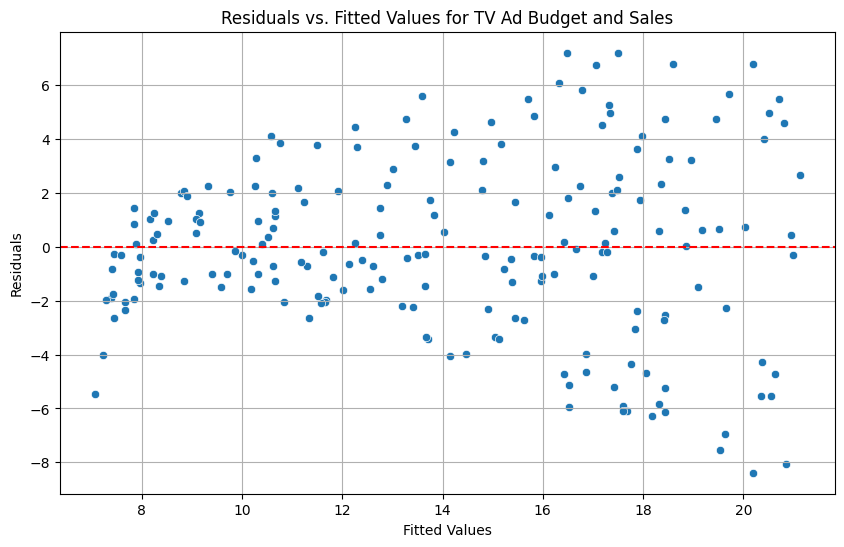

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_advert['y_pred'], y=df_advert['residuals'])
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values for TV Ad Budget and Sales')
plt.grid(True)
plt.show()

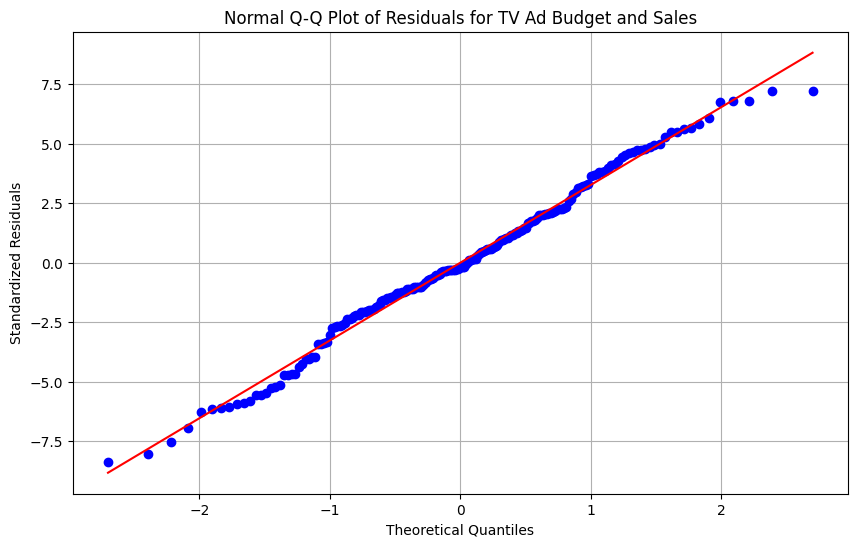

In [13]:
plt.figure(figsize=(10, 6))
stats.probplot(df_advert['residuals'], dist="norm", plot=plt)
plt.title('Normal Q-Q Plot of Residuals for TV Ad Budget and Sales')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.grid(True)
plt.show()

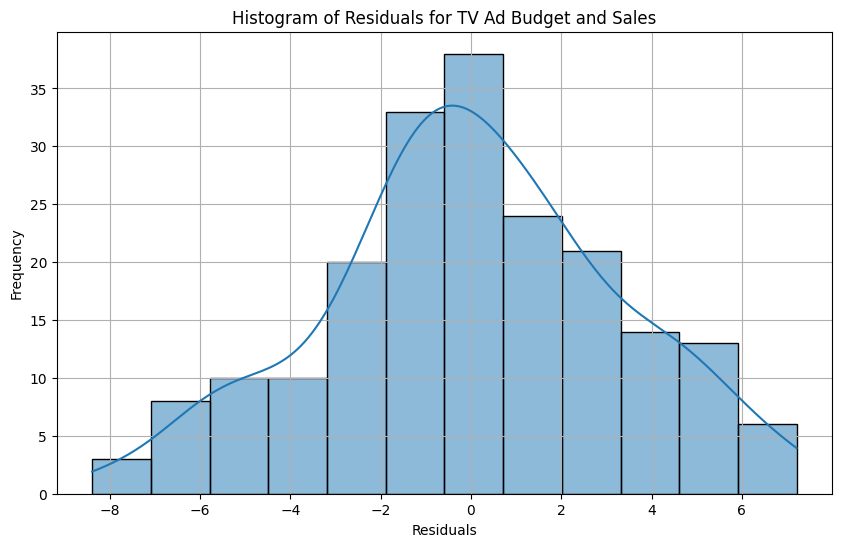

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df_advert['residuals'], kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals for TV Ad Budget and Sales')
plt.grid(True)
plt.show()

### Histogram of Residuals

Another way to check the normality of residuals is by plotting a histogram.

## Residual Analysis for House Prices Dataset

Now, let's perform the same residual analysis on the 'house_prices.csv' dataset. I will load the dataset and choose 'GrLivArea' as the independent variable (X) and 'SalePrice' as the dependent variable (y) for our simple linear regression model.

In [20]:
# Load the house_prices.csv dataset
house_df = pd.read_csv('/content/house_prices.csv')

# Display column names to verify
print("Column names in the 'house_prices' dataset:")
print(house_df.columns.tolist())

# Select 'sqft_living' as independent variable and 'price' as dependent variable
X_house = house_df['sqft_living']
y_house = house_df['price']

# Create a DataFrame for convenience
df_house = pd.DataFrame({'SqFtLiving': X_house, 'Price': y_house})

display(df_house.head())

Column names in the 'house_prices' dataset:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


,SqFtLiving,Price
0,1180,221900.0
1,2570,538000.0
2,770,180000.0
3,1960,604000.0
4,1680,510000.0


### Fit Simple Linear Regression Model for House Prices

In [21]:
# Add a constant to the independent variable for the intercept term
X_house_const = sm.add_constant(df_house['SqFtLiving'])

# Fit the OLS (Ordinary Least Squares) model
model_house = sm.OLS(df_house['Price'], X_house_const)
results_house = model_house.fit()

# Display the model summary
print(results_house.summary())

# Get predicted values and residuals
df_house['y_pred_house'] = results_house.predict(X_house_const)
df_house['residuals_house'] = results_house.resid

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                 2.100e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:30:27   Log-Likelihood:            -3.0027e+05
No. Observations:               21613   AIC:                         6.005e+05
Df Residuals:                   21611   BIC:                         6.006e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.358e+04   4402.690     -9.899      0.0

### Residual Plots for House Prices Linear Regression

Let's visualize the residuals to check the model assumptions for the house prices data.

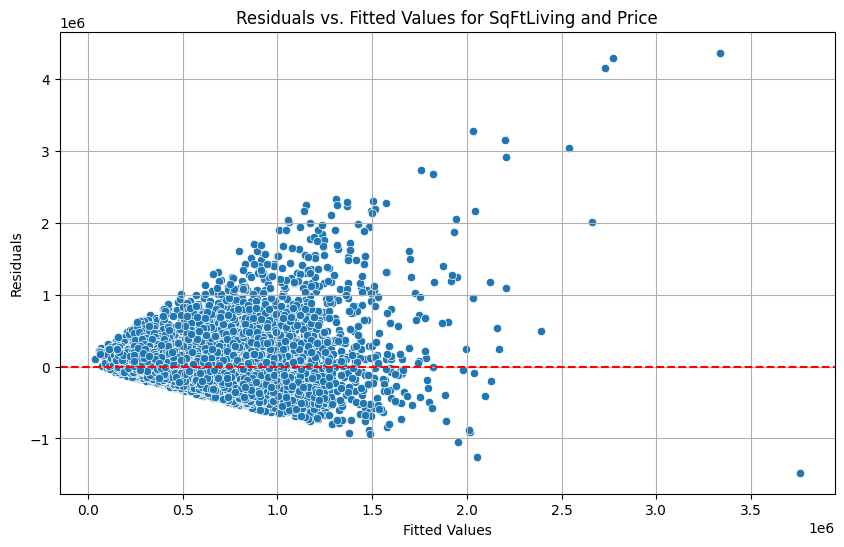

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_house['y_pred_house'], y=df_house['residuals_house'])
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values for SqFtLiving and Price')
plt.grid(True)
plt.show()

### Normal Q-Q Plot of Residuals for House Prices

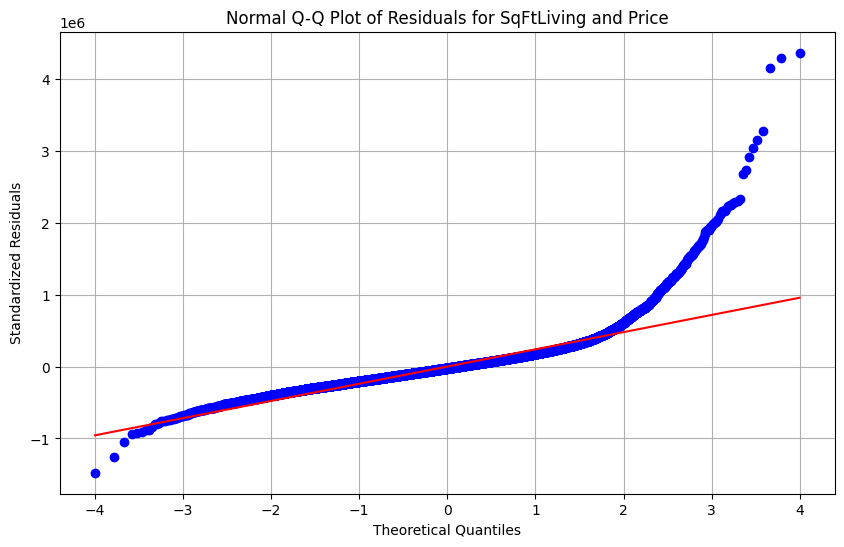

In [23]:
plt.figure(figsize=(10, 6))
stats.probplot(df_house['residuals_house'], dist="norm", plot=plt)
plt.title('Normal Q-Q Plot of Residuals for SqFtLiving and Price')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.grid(True)
plt.show()

### Histogram of Residuals for House Prices

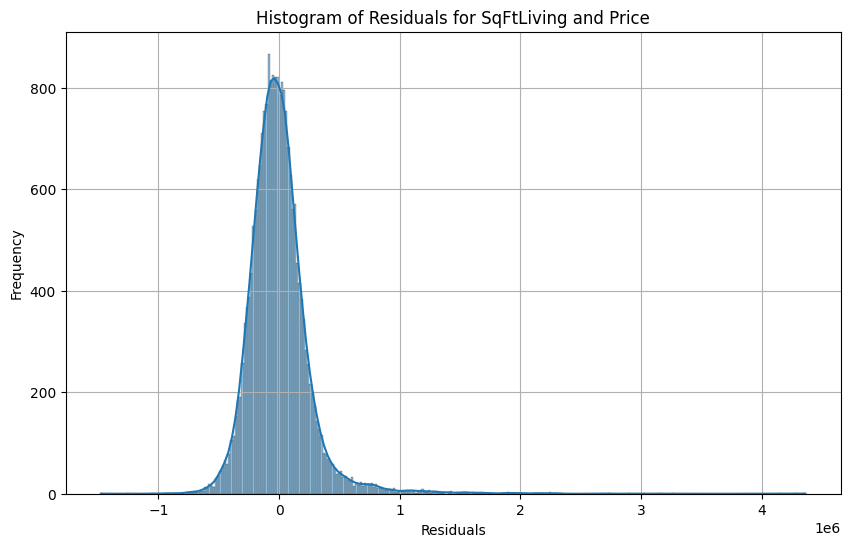

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df_house['residuals_house'], kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals for SqFtLiving and Price')
plt.grid(True)
plt.show()